# Gender Classifier Training

Binary gender classification (Male / Female) using a frozen ResNet50 backbone + small classification head on the UTKFace dataset.

- **Label:** `gender_id` — `0 = Male`, `1 = Female`
- **Backbone:** ResNet50 pretrained on ImageNet (frozen)
- **Framework:** TensorFlow / Keras

## 1. Environment Detection (Colab vs Local)

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Mount Google Drive if needed, or use /content directly
    DATA_DIR = Path("/content/data")
    CHECKPOINT_DIR = Path("/content/checkpoints")
else:
    NOTEBOOK_DIR = Path(".").resolve()
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    DATA_DIR = PROJECT_ROOT / "data"
    CHECKPOINT_DIR = PROJECT_ROOT / "models" / "gender_classifier"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR   = DATA_DIR / "utk_face"
TRAIN_CSV    = DATA_DIR / "splits" / "train_gender.csv"
VAL_CSV      = DATA_DIR / "splits" / "val_gender.csv"
TEST_CSV     = DATA_DIR / "splits" / "test.csv"
BEST_MODEL   = CHECKPOINT_DIR / "best_model.keras"

print(f"Running in Colab: {IN_COLAB}")
print(f"Data dir        : {DATA_DIR}")
print(f"Images dir      : {IMAGES_DIR}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")

Running in Colab: False
Data dir        : C:\Users\dltvn\dev\comp385\face_age_estimator\data
Images dir      : C:\Users\dltvn\dev\comp385\face_age_estimator\data\utk_face
Checkpoint dir  : C:\Users\dltvn\dev\comp385\face_age_estimator\models\gender_classifier


## 2. Imports & Hyperparameters

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 30
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.3
DENSE_UNITS  = 256
SEED         = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version : 2.20.0
GPUs available     : []


## 3. Data Loading & tf.data Pipeline

In [3]:
def load_dataframe(csv_path: Path) -> pd.DataFrame:
    """Load a split CSV and return only the columns we need."""
    df = pd.read_csv(csv_path)
    df["filepath"] = df["filename"].apply(
        lambda fname: str(IMAGES_DIR / fname)
    )
    df["label"] = df["gender_id"].astype(int)
    return df[["filepath", "label"]]


train_df = load_dataframe(TRAIN_CSV)
val_df   = load_dataframe(VAL_CSV)
test_df  = load_dataframe(TEST_CSV)

print(f"Train samples : {len(train_df)}")
print(f"Val   samples : {len(val_df)}")
print(f"Test  samples : {len(test_df)}")
print()
print("Train label distribution:")
print(train_df["label"].value_counts().rename({0: "Male", 1: "Female"}))

Train samples : 14104
Val   samples : 6045
Test  samples : 3556

Train label distribution:
label
Male      7373
Female    6731
Name: count, dtype: int64


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def parse_image(filepath: str, label: int):
    """Read, decode, resize and preprocess a single image."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)  # ResNet50 preprocessing
    return image, label


def augment(image, label):
    """Apply random augmentation to a training image."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, label


def make_dataset(
    df: pd.DataFrame,
    training: bool = False,
    batch_size: int = BATCH_SIZE,
) -> tf.data.Dataset:
    """Build a tf.data.Dataset from a DataFrame."""
    filepaths = df["filepath"].values
    labels    = df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

print("Datasets built successfully.")

Datasets built successfully.


### Sample batch visualisation

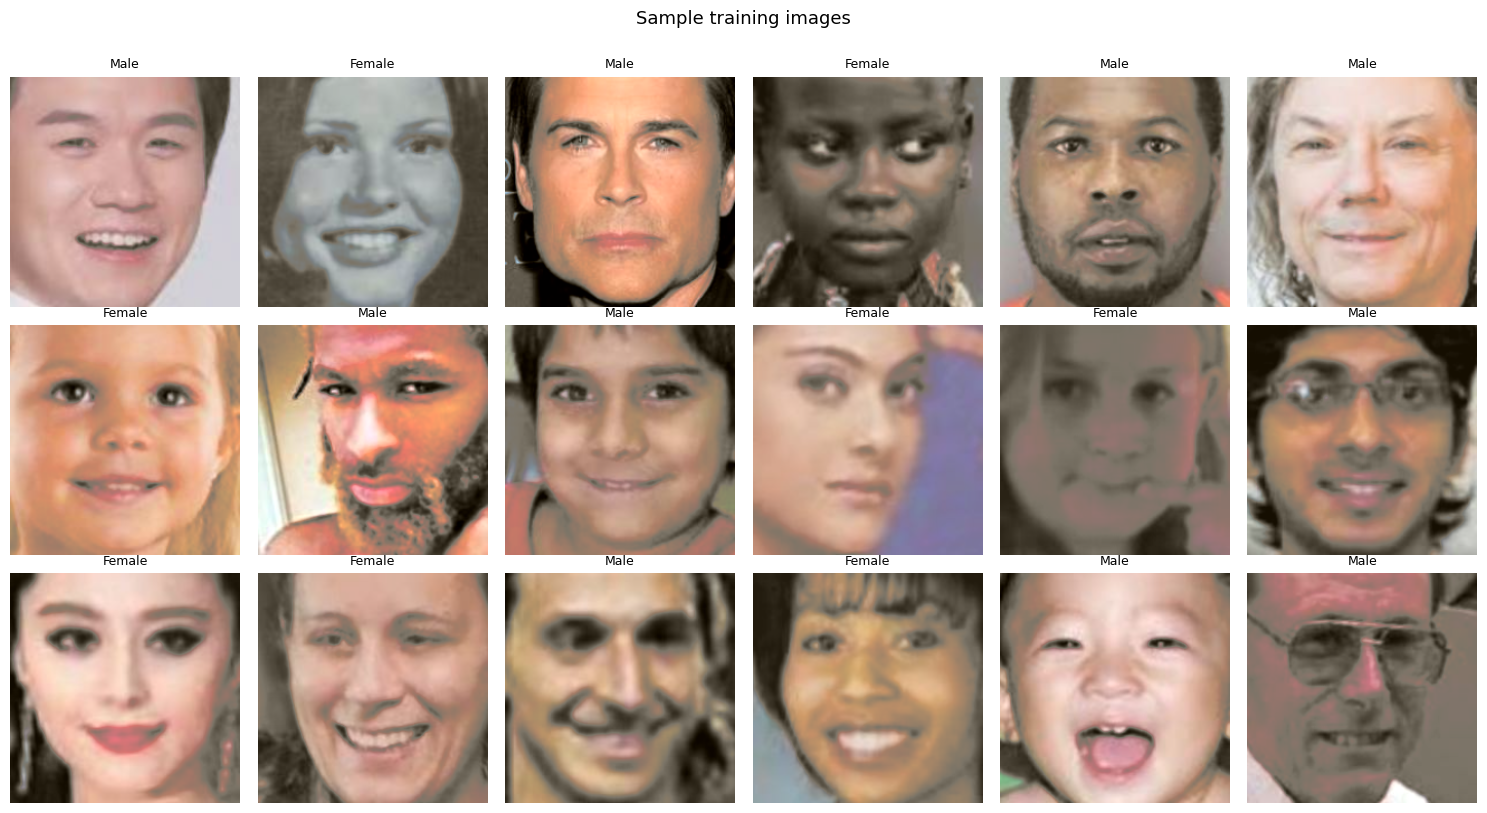

In [5]:
LABEL_NAMES = {0: "Male", 1: "Female"}

# Grab one batch for inspection (undo ResNet preprocessing for display)
sample_images, sample_labels = next(iter(train_ds))

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(sample_images):
        ax.axis("off")
        continue
    # ResNet50 preprocess_input subtracts ImageNet mean; undo for display
    img = sample_images[i].numpy()
    img = img + np.array([103.939, 116.779, 123.68])  # add back BGR mean
    img = img[..., ::-1]                               # BGR -> RGB
    img = np.clip(img / 255.0, 0, 1)
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[int(sample_labels[i])], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample training images", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Model Definition

In [6]:
def build_model(
    image_size: tuple = IMAGE_SIZE,
    dense_units: int = DENSE_UNITS,
    dropout_rate: float = DROPOUT_RATE,
    learning_rate: float = LEARNING_RATE,
) -> keras.Model:
    """Build gender classifier with frozen ResNet50 backbone.

    Args:
        image_size: Input image (height, width).
        dense_units: Number of units in the fully-connected head.
        dropout_rate: Dropout probability after the dense layer.
        learning_rate: Adam learning rate.

    Returns:
        Compiled Keras model.
    """
    # ── Backbone ─────────────────────────────────────────────────────────────
    backbone = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(*image_size, 3),
    )
    backbone.trainable = False  # freeze all backbone weights

    # ── Classification Head ───────────────────────────────────────────────────
    inputs = keras.Input(shape=(*image_size, 3), name="image_input")
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(dense_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="gender_output")(x)

    model = keras.Model(inputs, outputs, name="gender_classifier")

    # ── Compile ───────────────────────────────────────────────────────────────
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


if BEST_MODEL.exists():
    model = keras.models.load_model(str(BEST_MODEL))
    print(f"Resumed from checkpoint: {BEST_MODEL}")
else:
    model = build_model()
    print("No checkpoint found — starting from scratch.")

model.summary()

Resumed from checkpoint: C:\Users\dltvn\dev\comp385\face_age_estimator\models\gender_classifier\best_model.keras


Model: "gender_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gender_output (Dense)           │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,162,117 (95.99 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,049,604 (4.00 MB)

## 5. Callbacks

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured:
  - ModelCheckpoint
  - EarlyStopping
  - ReduceLROnPlateau


## 6. Training

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

print(f"\nTraining complete. Best model saved to: {BEST_MODEL}")

Epoch 1/30
 84/441 ━━━━━━━━━━━━━━━━━━━━ 7:29 1s/step - accuracy: 0.8534 - auc: 0.9325 - loss: 0.3394

## 7. Training Curves

In [ ]:
def plot_history(history: keras.callbacks.History) -> None:
    """Plot training and validation loss, accuracy and AUC curves."""
    hist  = history.history
    epochs_ran = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Loss
    axes[0].plot(epochs_ran, hist["loss"],     label="Train")
    axes[0].plot(epochs_ran, hist["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs_ran, hist["accuracy"],     label="Train")
    axes[1].plot(epochs_ran, hist["val_accuracy"], label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # AUC
    axes[2].plot(epochs_ran, hist["auc"],     label="Train")
    axes[2].plot(epochs_ran, hist["val_auc"], label="Val")
    axes[2].set_title("AUC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.suptitle("Training History", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_history(history)

## 8. Evaluation on Test Set

In [ ]:
# Load best checkpoint
best_model = keras.models.load_model(str(BEST_MODEL))
print(f"Loaded best model from: {BEST_MODEL}")

# Collect predictions over the full test set
y_true_list: list[int]   = []
y_prob_list: list[float] = []

for images, labels in test_ds:
    probs = best_model(images, training=False).numpy().flatten()
    y_true_list.extend(labels.numpy().tolist())
    y_prob_list.extend(probs.tolist())

y_true  = np.array(y_true_list)
y_probs = np.array(y_prob_list)
y_pred  = (y_probs >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_probs)

print(f"\nTest Accuracy : {acc:.4f}")
print(f"Test AUC      : {auc:.4f}")

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Male", "Female"]))

In [ ]:
import itertools


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: list[str],
) -> None:
    """Plot a labelled confusion matrix."""
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.tight_layout()
    plt.show()


cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, class_names=["Male", "Female"])